In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn import functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
block_size = 8
batch_size = 4
learning_rate = 7e-4
max_iters = 50000
eval_iters = 1000

cuda


In [17]:
with open('books.txt', 'r', encoding = 'utf') as f:
    text = f.read()
chars = sorted(set(text))
vocab_size = len(chars)

In [18]:
string_to_int = { ch:i for i, ch in enumerate(chars)}
int_to_string = { i:ch for i, ch in enumerate(chars)}
encode = lambda s: [string_to_int[c] for c in s]
decode = lambda v: ''.join([int_to_string[c] for c in v])



In [19]:
data = torch.tensor(encode(text), dtype = torch.long)

In [20]:
n = int(0.8*len(data))
train_data = data[ :n]
valid_data = data[n: ]

def get_batch(split):
    data = train_data if split == "train" else valid_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+1+block_size] for i in ix])
    x, y = x.to(device), y.to(device)
    return x,y

x, y = get_batch("train")



In [21]:
def evaluate_loss():
    out = {}
    model.eval()
    for i in ["train", "test"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(i)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[i] = losses.mean()
    model.train()
    return out
        

In [22]:
class BiGramLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_emb_tb = nn.Embedding(vocab_size, vocab_size)

    def forward(self, index, targets = None):
        logits = self.token_emb_tb(index)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, index, max_new_tokens):

        for _ in range(max_new_tokens):

            logits, loss = self.forward(index)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim = -1)
            index_next = torch.multinomial(probs, num_samples = 1)
            index = torch.cat((index, index_next), dim = 1)

        return index

model = BiGramLM(vocab_size)
m = model.to(device)


In [23]:
"""x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print("when input is ", context, "print" , target)"""

'x = train_data[:block_size]\ny = train_data[1:block_size+1]\nfor t in range(block_size):\n    context = x[:t+1]\n    target = y[t]\n    print("when input is ", context, "print" , target)'

step: 0, 4.9979, 5.0089
step: 1000, 4.4282, 4.4366
step: 2000, 3.9699, 3.9768
step: 3000, 3.5957, 3.6194
step: 4000, 3.3084, 3.3453
step: 5000, 3.0965, 3.1294
step: 6000, 2.9379, 2.9753
step: 7000, 2.8119, 2.8409
step: 8000, 2.7184, 2.7686
step: 9000, 2.6533, 2.7034
step: 10000, 2.6113, 2.6552
step: 11000, 2.5790, 2.6250
step: 12000, 2.5509, 2.5992
step: 13000, 2.5275, 2.5869
step: 14000, 2.5043, 2.5648
step: 15000, 2.4923, 2.5466
step: 16000, 2.4886, 2.5189
step: 17000, 2.4773, 2.5173
step: 18000, 2.4820, 2.5261
step: 19000, 2.4588, 2.5189
step: 20000, 2.4579, 2.5089
step: 21000, 2.4490, 2.5139
step: 22000, 2.4479, 2.5100
step: 23000, 2.4373, 2.5098
step: 24000, 2.4447, 2.4826
step: 25000, 2.4360, 2.4987
step: 26000, 2.4267, 2.4959
step: 27000, 2.4469, 2.4888
step: 28000, 2.4460, 2.4818
step: 29000, 2.4486, 2.4915
step: 30000, 2.4417, 2.4971
step: 31000, 2.4350, 2.5056
step: 32000, 2.4534, 2.5019
step: 33000, 2.4409, 2.4868
step: 34000, 2.4394, 2.4981
step: 35000, 2.4262, 2.4824
step:

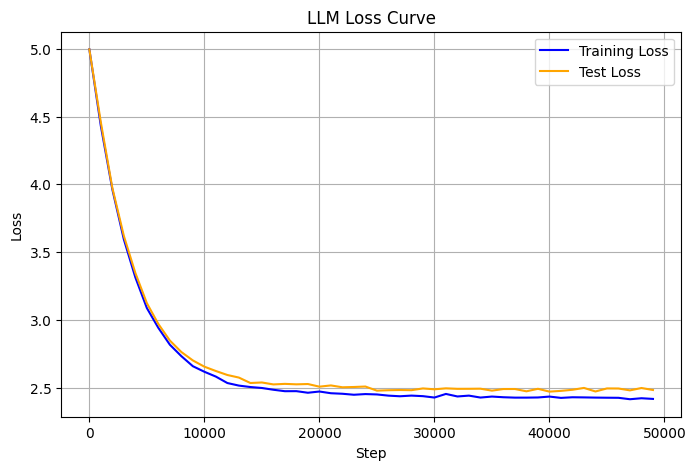

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate)
step = []
train_loss = []
test_loss = []
for iter in range(max_iters):

    if iter % eval_iters == 0 :
        print(f"step: {iter}, {evaluate_loss()["train"]:.4f}, {evaluate_loss()["test"]:.4f}")
        step.append(iter)
        train_loss.append(evaluate_loss()["train"])
        test_loss.append(evaluate_loss()["test"])
        
    xb, yb = get_batch("train")

    logits, loss = model.forward(xb, yb)
    optimizer.zero_grad(set_to_none = True)
    loss.backward()
    optimizer.step()

print(loss.item())
plt.figure(figsize=(8, 5))
plt.plot(step, train_loss, label='Training Loss', color='blue')
plt.plot(step, test_loss, label='Test Loss', color='orange')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('LLM Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
context = torch.zeros((1,1), dtype = torch.long, device = device)
gen_chars = decode(m.generate(context, max_new_tokens = 1000)[0].tolist())
print(gen_chars)


one Buthedante a ile ankld toveethounilldestove,” t;

owf rste eded I qughato. orkere henofok Cr. as pand rt he m beay am agat tuly artytathes.
“Th.
is, Dore ashise.
“iz a htheitellfre ang s.
t I andis bethemesianofureay wacel, ate thecag wins Donghsh,”
ontrivomue?”
ly we
“Yowe dee te hand spe henditusoul fisarint ne fof cre cand HùYongsooul a a


ctoion, h t or t tlere sthelldyso I nd, s? Asoff d met’lllillleslved t he

cue apsce f dy s be torate thed clalonde lea Ouro t copancks hore  itoclar, Whony Nyot mecheanor ize her ad rtuey, therthetheve, by
Burerolat mu mo ler herup-6t hast Lithe a dancicereeed
ho?

Che s “I
wace  I
th.” angat stheeiand mede ad ot le

yf acterid t agrotr uliplecheit I ske.
kinlibupeny.
tr ners eede

“y s nde ots thefis, We.  ad ane shide rait ned auing ue hureneeed tome t mokse itcasetheefin witothe fransalont cqulttinosisele I’s, Southiver nmiclf y tomicis vouthenat.” o old llo fetharef y moune wind hithe
The cankirthe aspoked is, memabe Sn andino mustomoff